# Dimensionality Reduction Exercise

This notebook solves the dimensionality reduction exercise on the Human Activity Recognition dataset.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.feature_selection import SelectKBest, f_classif, RFE
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, ConfusionMatrixDisplay

plt.style.use("seaborn-v0_8-whitegrid")


def find_data_dir(*relative_paths: str) -> Path:
    """Find the real UCI HAR dataset directory from the notebook folder or one of its parents."""
    for root in [Path.cwd(), *Path.cwd().parents]:
        for rel_path in relative_paths:
            candidate = (root / rel_path).resolve()
            expected_file = candidate / "train" / "X_train.txt"
            if expected_file.exists():
                return candidate
    raise FileNotFoundError(f"Could not find a valid UCI HAR dataset in: {relative_paths}")


# Locate the real dataset folder, not just the placeholder directory stored in the repo.
data_root = find_data_dir(
    "UCI HAR Dataset",
    "exercises/UCI HAR Dataset",
)

# Load the train and test splits, then standardize the predictors before reduction.
X_train = pd.read_csv(data_root / "train" / "X_train.txt", sep=r"\s+", header=None)
y_train = pd.read_csv(data_root / "train" / "y_train.txt", header=None).squeeze()
X_test = pd.read_csv(data_root / "test" / "X_test.txt", sep=r"\s+", header=None)
y_test = pd.read_csv(data_root / "test" / "y_test.txt", header=None).squeeze()

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Train shape:", X_train_scaled.shape)
print("Test shape :", X_test_scaled.shape)


Train shape: (7352, 561)
Test shape : (2947, 561)


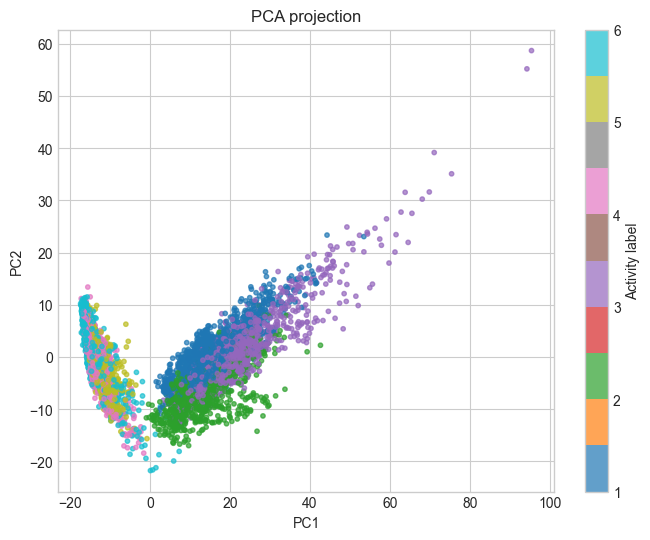

Explained variance ratio: [0.50781172 0.0658068 ]


In [2]:
# PCA gives an unsupervised two-dimensional summary of the activity signals.
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_train_scaled)

plt.figure(figsize=(8, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y_train, cmap="tab10", s=10, alpha=0.7)
plt.title("PCA projection")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.colorbar(label="Activity label")
plt.show()

print("Explained variance ratio:", pca.explained_variance_ratio_)

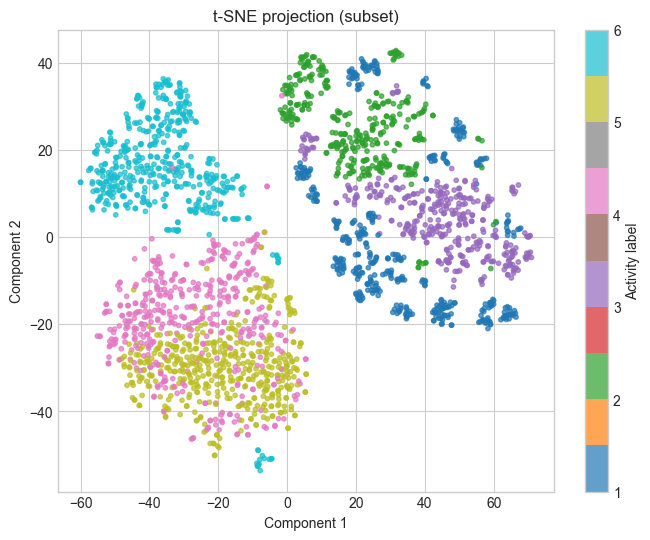

In [3]:
# t-SNE is applied on a subset because it is mainly a visualization tool and is computationally heavier.
rng = np.random.RandomState(42)
subset_idx = rng.choice(len(X_train_scaled), size=min(2500, len(X_train_scaled)), replace=False)
X_subset = X_train_scaled[subset_idx]
y_subset = y_train.iloc[subset_idx]

tsne = TSNE(n_components=2, random_state=42, perplexity=30, init="pca")
X_tsne = tsne.fit_transform(X_subset)

plt.figure(figsize=(8, 6))
plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c=y_subset, cmap="tab10", s=10, alpha=0.7)
plt.title("t-SNE projection (subset)")
plt.xlabel("Component 1")
plt.ylabel("Component 2")
plt.colorbar(label="Activity label")
plt.show()

In [ ]:
# LDA is supervised, while SelectKBest and RFE keep the most informative original variables.
lda = LinearDiscriminantAnalysis(n_components=2)
X_lda = lda.fit_transform(X_train_scaled, y_train)

selector = SelectKBest(score_func=f_classif, k=2)
X_kbest = selector.fit_transform(X_train_scaled, y_train)
selected_features = selector.get_support(indices=True)
print("SelectKBest feature indices:", selected_features)

rfe_estimator = LogisticRegression(max_iter=2000, random_state=42)
rfe = RFE(estimator=rfe_estimator, n_features_to_select=20)
rfe.fit(X_train_scaled, y_train)
selected_rfe = np.where(rfe.support_)[0]
print("RFE selected feature indices (20 features):", selected_rfe)

SelectKBest feature indices: [ 40 366]


,Representation,Accuracy
0,Original,0.927044
3,SelectKBest,0.631490
2,LDA (2D),0.616559
1,PCA (2D),0.520869
4,RFE,0.477435


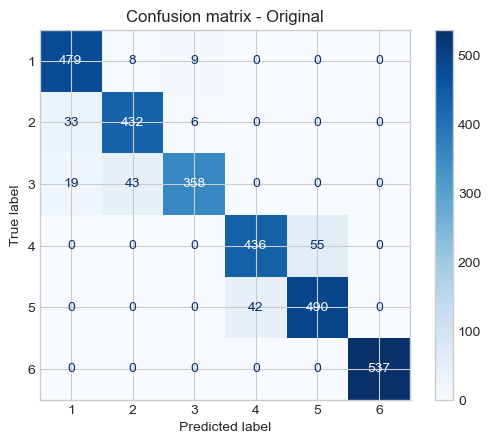

In [ ]:
# Evaluate the different representations with the same downstream classifier.
representations = {
    "Original": (X_train_scaled, X_test_scaled),
    "PCA (2D)": (pca.transform(X_train_scaled), pca.transform(X_test_scaled)),
    "LDA (2D)": (lda.transform(X_train_scaled), lda.transform(X_test_scaled)),
    "SelectKBest": (selector.transform(X_train_scaled), selector.transform(X_test_scaled)),
    "RFE": (rfe.transform(X_train_scaled), rfe.transform(X_test_scaled)),
}

results = []
for name, (Xtr, Xte) in representations.items():
    clf = RandomForestClassifier(n_estimators=200, random_state=42)
    clf.fit(Xtr, y_train)
    y_pred = clf.predict(Xte)
    acc = accuracy_score(y_test, y_pred)
    results.append({"Representation": name, "Accuracy": acc})
    print(f"{name}: accuracy = {acc:.4f}")

results_df = pd.DataFrame(results).sort_values("Accuracy", ascending=False)
display(results_df)

best_representation = results_df.iloc[0]["Representation"]
print("Best representation:", best_representation)

best_model = RandomForestClassifier(n_estimators=200, random_state=42)
Xtr_best, Xte_best = representations[best_representation]
best_model.fit(Xtr_best, y_train)
ConfusionMatrixDisplay.from_predictions(y_test, best_model.predict(Xte_best), cmap="Blues")
plt.title(f"Confusion matrix - {best_representation}")
plt.show()

## Interpretation

- PCA gives a compact unsupervised summary of the data.
- t-SNE is very useful for visualization, but less suitable as a production feature space.
- LDA often provides the clearest separation because it uses the labels.
- SelectKBest and RFE are useful when the goal is to keep a very small number of original features.